# generation of beautiful graphics using seaborn 


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import style_config
from style_config import COLORS


### APC Adoption Across Regions 
(approx. pg. 11)

In [3]:
apc_adopt_1 = {
    'Region': [
        'Latin America & Caribbean',
        'Europe & Central Asia',
        'East Asia & Pacific',
        'North America',
        'South Asia',
        'Sub-Saharan Africa',
        'Middle East & North Africa',
        'Unknown'
    ],
    'Journals not charging APCs (n)': [380, 337, 101, 66, 29, 18, 14, 151],
    'Journals charging APCs (n)':     [ 18,  40, 101, 11, 21, 24, 15,  22]
}

apc_adopt_1 = pd.DataFrame(apc_adopt_1)
print(apc_adopt_1.to_string(index=False))

                    Region  Journals not charging APCs (n)  Journals charging APCs (n)
 Latin America & Caribbean                             380                          18
     Europe & Central Asia                             337                          40
       East Asia & Pacific                             101                         101
             North America                              66                          11
                South Asia                              29                          21
        Sub-Saharan Africa                              18                          24
Middle East & North Africa                              14                          15
                   Unknown                             151                          22


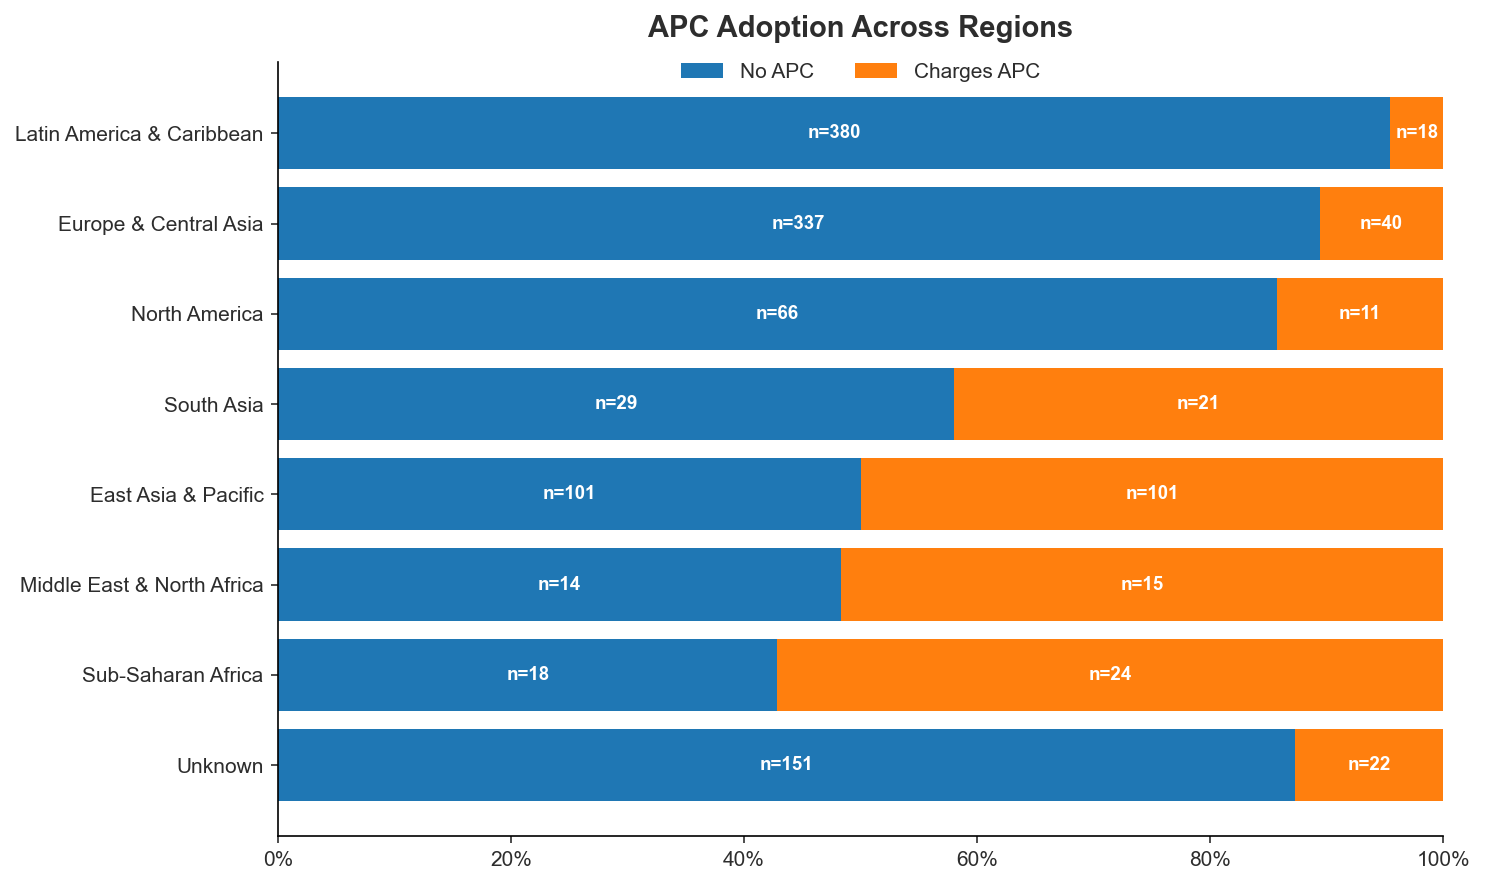

In [4]:
df = pd.DataFrame(apc_adopt_1).set_index('Region')
df['total']      = df.sum(axis=1)
df['pct_apc']    = df['Journals charging APCs (n)'] / df['total']
df['pct_no_apc'] = df['Journals not charging APCs (n)'] / df['total']
df = df.sort_values('pct_apc', ascending=False)
unknown = df.loc[['Unknown']]
df = pd.concat([unknown, df.drop('Unknown')])

# --- Plot ---
fig, ax = plt.subplots()

bars_no_apc = ax.barh(df.index, df['pct_no_apc'],
                      color=COLORS['primary'], label='No APC')
bars_apc    = ax.barh(df.index, df['pct_apc'], left=df['pct_no_apc'],
                      color=COLORS['secondary'], label='Charges APC')

# --- Labels inside bars ---
for bar, n in zip(bars_apc, df['Journals charging APCs (n)']):
    w = bar.get_width()
    if w > 0.04:
        ax.text(bar.get_x() + w / 2, bar.get_y() + bar.get_height() / 2,
                f'n={n}', ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

for bar, n in zip(bars_no_apc, df['Journals not charging APCs (n)']):
    w = bar.get_width()
    ax.text(bar.get_x() + w / 2, bar.get_y() + bar.get_height() / 2,
            f'n={n}', ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')

# --- Formatting ---
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlim(0, 1)
ax.set_title('APC Adoption Across Regions')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 0.95),
          ncols=2, bbox_transform=ax.transAxes)

plt.tight_layout()
plt.show()

maybe increase font size/make colours different

### APC Adoption By Journal Size
(approx. pg. 12/13)

In [7]:
apc_adopt_2 = {
    'Decile': [1, 2, 3, 4, 5, 6, 7, 8, 9, '10s'],
    'Number of articles': [
        '1-14', '15-21', '22-28', '29-35', '36-43',
        '44-53', '54-68', '69-90', '91-140', '141-3931'
    ],
    'No APC (n)':  [106, 119, 102, 93, 84, 99, 111, 95, 79, 85],
    'Yes APC (n)': [16,   18,  21, 27, 23, 19,  22, 27, 30, 36],
}

df = pd.DataFrame(apc_adopt_2)
print(df.to_string(index=False))

Decile Number of articles  No APC (n)  Yes APC (n)
     1               1-14         106           16
     2              15-21         119           18
     3              22-28         102           21
     4              29-35          93           27
     5              36-43          84           23
     6              44-53          99           19
     7              54-68         111           22
     8              69-90          95           27
     9             91-140          79           30
   10s           141-3931          85           36


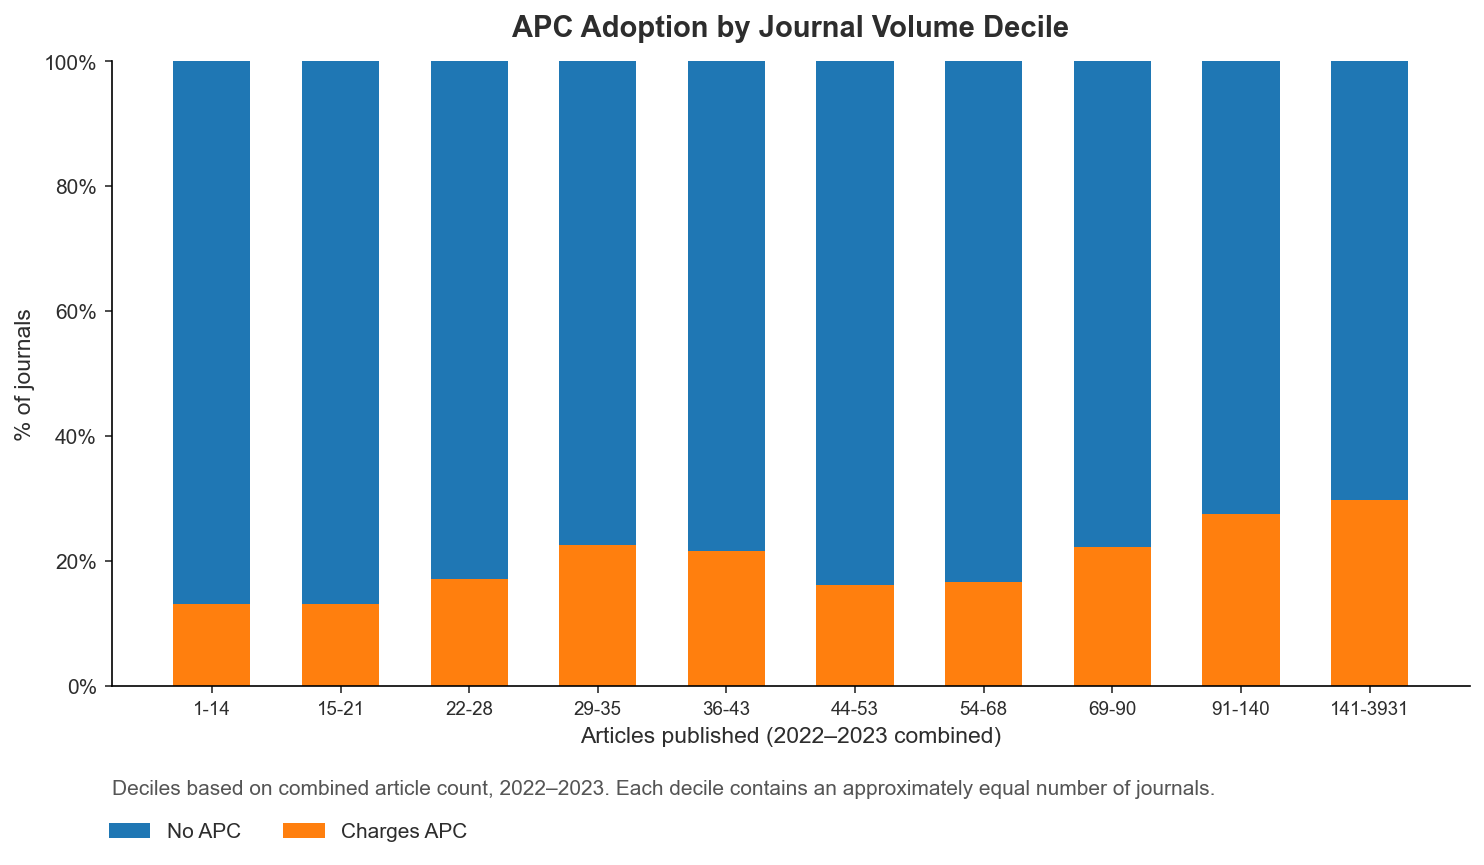

In [20]:
df = pd.DataFrame(apc_adopt_2)

df['total']      = df['No APC (n)'] + df['Yes APC (n)']
df['pct_apc']    = df['Yes APC (n)'] / df['total']
df['pct_no_apc'] = df['No APC (n)']  / df['total']

labels = df['Number of articles']

TITLE   = 'APC Adoption by Journal Volume Decile'
XLABEL  = 'Articles published (2022–2023 combined)'
YLABEL  = '% of journals'
CAPTION = ('Deciles based on combined article count, 2022–2023. '
           'Each decile contains an approximately equal number of journals.')

fig, ax = plt.subplots()

x = range(len(df))

bars_no_apc = ax.bar(x, df['pct_no_apc'], bottom=df['pct_apc'],
                     color=COLORS['primary'],   label='No APC',      width=0.6)
bars_apc    = ax.bar(x, df['pct_apc'],
                     color=COLORS['secondary'], label='Charges APC', width=0.6)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 1)
ax.set_xlabel(XLABEL)
ax.set_ylabel(YLABEL)
ax.set_title(TITLE)

ax.legend(loc='lower center', bbox_to_anchor=(0.13, -0.28),
          ncols=2, bbox_transform=ax.transAxes)

fig.text(0, -0.15, CAPTION, ha='left', va='top',
         fontsize=10, color='#555555', transform=ax.transAxes)

plt.tight_layout()
plt.show()

### APC Funding and journal survival 

(pg 13)

NEED THE DATA FOR THIS ONE!! 

### APC Pricing and Publisher Ownership

(pg. 14/15)

In [40]:
apc_pub_own = {
    'Ownership Type': [
        'Academic department or other unit',
        'Academic society or association',
        'Group of academics',
        'University press or publishing unit',
        'Non-profit publisher',
        'Commercial publisher',
        'Government agency',
        'University library',
    ],
    'Less than $500':  [119, 60, 49, 47, 33, 30, 30, 24],
    '$500-$1000':      [  7,  1,  1,  1,  0,  3,  0,  0],
    '$1001-$2000':     [  5,  2,  1,  1,  4,  0,  0,  0],
    'More than $2000': [  0,  0,  0,  1,  0,  5,  0,  0],
}

df = pd.DataFrame(apc_pub_own).set_index('Ownership Type')
df

,Less than $500,$500-$1000,$1001-$2000,More than $2000
Ownership Type,,,,
Academic department or other unit,119,7,5,0
Academic society or association,60,1,2,0
Group of academics,49,1,1,0
University press or publishing unit,47,1,1,1
Non-profit publisher,33,0,4,0
Commercial publisher,30,3,0,5
Government agency,30,0,0,0
University library,24,0,0,0


,Less than $500,$500-$1000,$1001-$2000,More than $2000,total
Ownership Type,,,,,
Academic department or other unit,119,7,5,0,131
Academic society or association,60,1,2,0,63
Group of academics,49,1,1,0,51
University press or publishing unit,47,1,1,1,50
Non-profit publisher,33,0,4,0,37
Commercial publisher,30,3,0,5,38
Government agency,30,0,0,0,30
University library,24,0,0,0,24


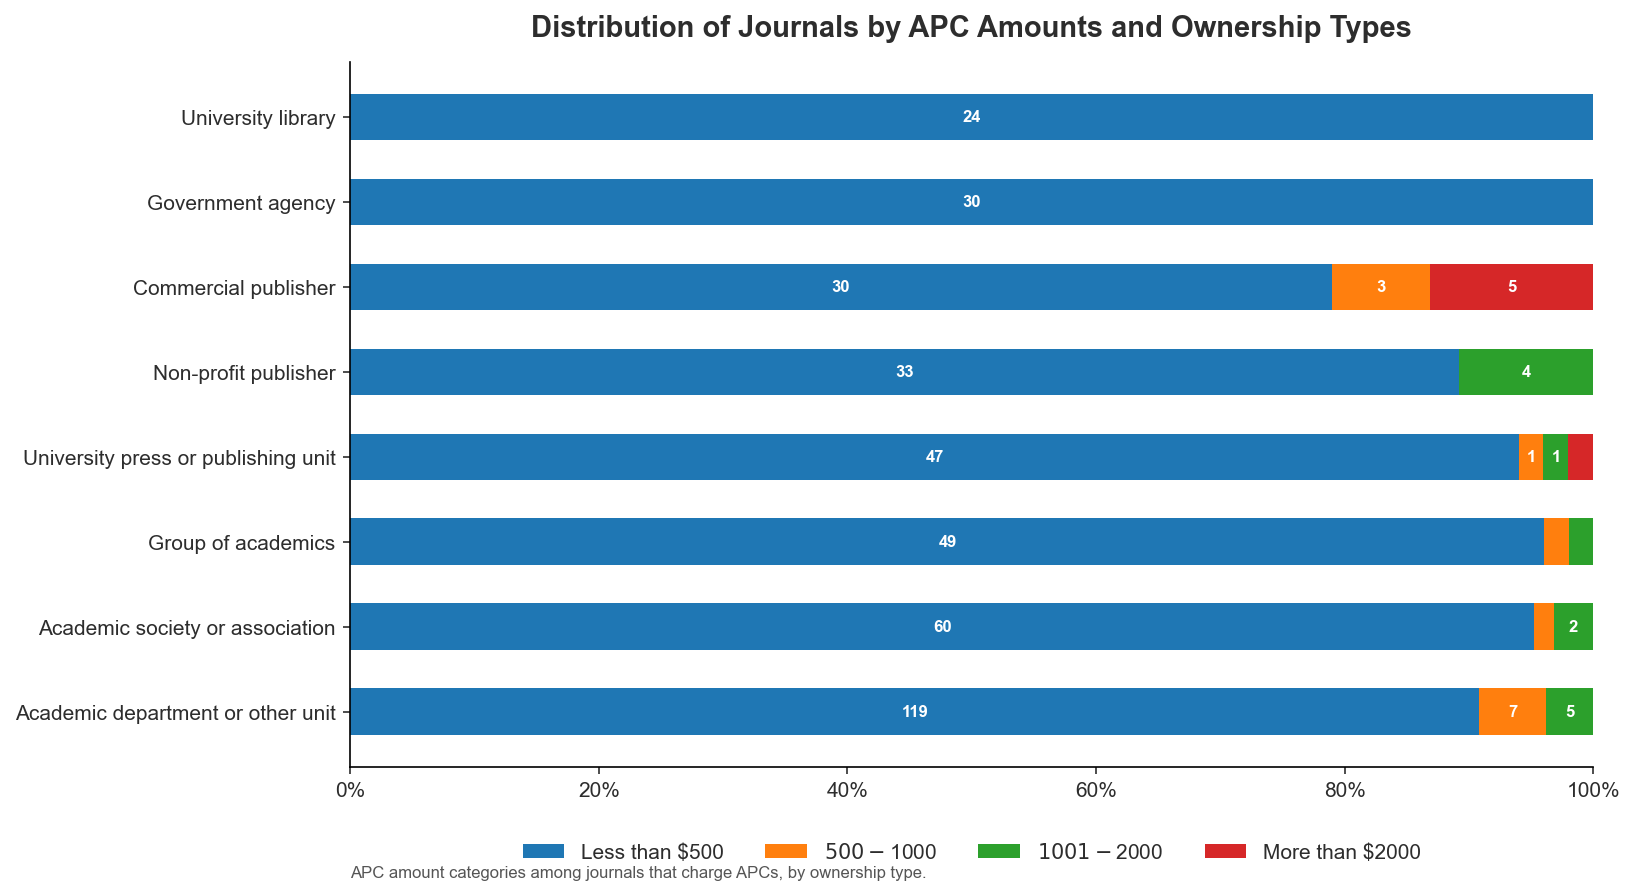

In [54]:
df = pd.DataFrame(apc_pub_own).set_index('Ownership Type')
# --- Compute percentages ---
df['total'] = df.sum(axis=1, numeric_only=True).astype(int)
display(df)
apc_cols = ['Less than $500', '$500-$1000', '$1001-$2000', 'More than $2000']
pct_df = df[apc_cols].div(df['total'], axis=0)

# Sort by 'Less than $500' descending so largest bar is on top
df = df.sort_values('Less than $500', ascending=True)
df = df.loc[pct_df.index]  # keep raw counts aligned

# --- Editable text ---
TITLE   = 'Distribution of Journals by APC Amounts and Ownership Types'
XLABEL  = ''
YLABEL  = ''
CAPTION = 'APC amount categories among journals that charge APCs, by ownership type.'

# --- Colours: 4-step sequential from palette ---
BAR_COLORS = [COLORS['palette'][0], 
              COLORS['palette'][1], 
              COLORS['palette'][2], 
              COLORS['palette'][3]]

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 6))

lefts = [0] * len(pct_df)
bars_list = []

for col, color in zip(apc_cols, BAR_COLORS):
    bars = ax.barh(pct_df.index, pct_df[col], left=lefts,
                   color=color, label=col, height=0.55)
    bars_list.append((bars, col))
    lefts = [l + v for l, v in zip(lefts, pct_df[col])]

# --- Labels inside bars (only if segment wide enough) ---
for bars, col in bars_list:
    for bar, region in zip(bars, pct_df.index):
        w = bar.get_width()
        if w > 0.02:
            n = df.loc[region, col]
            ax.text(bar.get_x() + w / 2, bar.get_y() + bar.get_height() / 2,
                    str(int(n)), ha='center', va='center',
                    color='white', fontsize=8, fontweight='bold')

# --- Formatting ---
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlim(0, 1)
ax.set_title(TITLE)
ax.set_xlabel(XLABEL)
ax.set_ylabel(YLABEL)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
          ncols=4, bbox_transform=ax.transAxes)

fig.text(0.0, -0.14, CAPTION, ha='left', va='top',
         fontsize=8, color='#555555', transform=ax.transAxes)

plt.tight_layout()
plt.show()